In [1]:
import os
import glob
import sys
import dill
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from yaml import safe_load, YAMLError, dump
from tabulate import tabulate
from scipy.interpolate import RectBivariateSpline
from scipy.stats import norm

import config as cfg 
import post_bdtlh_efficiency_finder as eff_finder
import bdt_lh_cut_opt_with_n_interp as opt
plt.style.use('fcc.mplstyle')

In [2]:
#load dictionary of N_remaining from spline (ie. N remaining fior different BFT cuts - essentially efficiency map)
save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/'

with open(os.path.join(opt.set_outputpath(save_path), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict = dill.load(dill_file)

with open(os.path.join(opt.set_outputpath(save_path), "N_remaining_dictionary"), "rb") as dill_file:
    N_dict = dill.load(dill_file)

#Load dataframe with bdtlh version applied
data={}
dir = cfg.fccana_opts["outputDir"]["prelim_cuts_full"]
folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut' 
for sample in cfg.samples:
    data[sample] = pd.read_pickle(os.path.join(dir,folder,f'{sample}.pkl'))

# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)

#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus

# find optimum cut
FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = opt.run_2d_optimisation(interp_N_dict,lrange_plot=(0.995,1) ,hrange_plot=(0.995,1), nlh=500 , sig_BF=1e-6, incl_ZqqBFerror = False)
indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]
print(l_cut)
print(h_cut)

#cut data on optimal BDT cut
cut_data = full_data.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')

Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       168.757 |               0.9996 |               0.9996 |
+---------------+----------------------+----------------------+
0.9996492985971944
0.9996292585170341


0.046708960655237296
[[21006.45184846 23091.12129427]
 [17705.72123736 27615.25511614]]


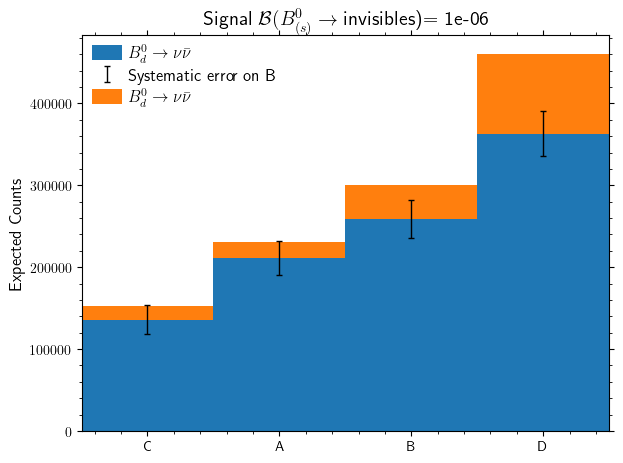

In [3]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in sublist]

eventsProcessed_dict = cfg.eventsProcessed    
signal_bf =1e-6
n_exp_arr=[]
n_exp_err_arr=[]
components =  ['hadronic_background','combined_signal']
i=0
tot_arr = [0,0,0,0]
samples = flatten_list([cfg.sample_allocations[component] for component in components])

N_dict_MC={}
for decay in samples:
    h=np.histogram2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=(2,2),density=False,range = [[h_cut, 1], [l_cut, 1]])
    N_dict_MC[decay] =  h[0] 
N_dict_MC

efficienies, efficiencies_err, N_dict_MC = eff_finder.get_eff_from_nMC_list(N_dict_MC)

per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err=eff_finder.get_n_expected_components(efficienies, efficiencies_err,signal_bf=1e-6)

S, B, S_err, B_err = eff_finder.get_total_SB(per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err)

tot_arr=[0,0,0,0]
for i in range(2):
    num=[B,S]
    h=num[i]
    x = np.array([['A','B'],['C','D']])
    plt.bar([x[1,0],x[0,0],x[0,1],x[1,1]],[h[1,0],h[0,0],h[0,1],h[1,1]],label=cfg.titles[decay], bottom=tot_arr, width=1.0)
    if i==0:
        plt.errorbar([x[1,0],x[0,0],x[0,1],x[1,1]],[B[1,0],B[0,0],B[0,1],B[1,1]], [B_err[1,0],B_err[0,0],B_err[0,1],B_err[1,1]],label='Systematic error on B',  fmt='None', ecolor='black')
        
    tot_arr =  [sum(x) for x in zip(tot_arr, [h[1,0],h[0,0],h[0,1],h[1,1]])]
    
plt.title(r'Signal $\mathcal{B}(B^0_{(s)}\rightarrow{}$invisibles)$=$ '+ f'{signal_bf}')
plt.legend()
plt.ylabel('Expected Counts')
print(np.sqrt(np.sum(B_err**2))/np.sum(B))
print(B_err)

In [5]:
#If instead only use one bin
eventsProcessed_dict = cfg.eventsProcessed    
signal_bf =1e-6
n_exp_arr=[]
n_exp_err_arr=[]
components =  ['hadronic_background','combined_signal']
i=0
tot_arr = [0,0,0,0]
samples = flatten_list([cfg.sample_allocations[component] for component in components])

N_dict_MC={}
for decay in samples:
    h=np.histogram2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=(1,1),density=False,range = [[h_cut, 1], [l_cut, 1]])
    N_dict_MC[decay] =  h[0] 
N_dict_MC

efficienies, efficiencies_err, N_dict_MC =eff_finder.get_eff_from_nMC_list(N_dict_MC)

per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err=eff_finder.get_n_expected_components(efficienies, efficiencies_err,signal_bf=1e-6)

S, B, S_err, B_err = eff_finder.get_total_SB(per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err)

print(np.sqrt(np.sum(B_err**2))/np.sum(B))
print(B_err)

0.04711571511026776
[[45677.51157868]]


## Developing functions

In [7]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in sublist]


def set_outputpath(outputpath):
    if not os.path.exists(outputpath):
        os.makedirs(outputpath)
    return outputpath


def make_final_binning_plot(df, interp_N_dict, lrange_interp_N_dict=(0.995,1) ,hrange_interp_N_dict=(0.995,1),signal_BF=1e-6, eventsProcessed_dict = cfg.eventsProcessed , histbins=(2,2), components =  ['hadronic_background','combined_signal'], nMC_plots=False, final_plot_path = None):
    
    def histogram_settings():
        hist_settings = { allocation: {} for allocation in cfg.sample_allocations }
        total_color = { allocation: {} for allocation in cfg.sample_allocations }
        for allocation in cfg.sample_allocations:
            samples = cfg.sample_allocations[allocation]
            if allocation=='combined_signal':
                hist_settings[allocation]['edgecolor'] =plt.cm.Blues( np.linspace(0, 1, 6)[3:-1] ) 
                hist_settings[allocation]['facecolor'] = ['none','none']
                hist_settings[allocation]['hatch'] = ['////',r'\\\\']
            elif allocation=='hadronic_background':
                hist_settings[allocation]['facecolor'] = plt.cm.Reds_r( np.linspace(0, 1, 6)[1:-1] )
                hist_settings[allocation]['edgecolor'] = ['none','none','none','none'] 
                hist_settings[allocation]['hatch'] =  [None,None,None,None] 
        return hist_settings
    
    print('--> Finding optimum cut')
    # find optimum cut
    FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = opt.run_2d_optimisation(interp_N_dict,lrange_plot=lrange_interp_N_dict ,hrange_plot=hrange_interp_N_dict, nlh=500 , sig_BF=signal_BF, incl_ZqqBFerror = False)
    indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
    l_cut = lsearch[indices[0]]
    h_cut = hsearch[indices[1]]

    #cut df on optimal BDT cuts
    cut_data = full_data.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')

    # define samples want from components input 
    samples = flatten_list([cfg.sample_allocations[component] for component in components])

    print('--> Finding number of events per bin')
    # get number of events per bin in MC using np.2d histogram
    N_dict_MC={}
    
    for decay in samples:
        
        if nMC_plots ==True:
            h=plt.hist2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=histbins, cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
            plt.ylabel('1-P(light)')
            plt.xlabel('1-P(heavy)') 
            plt.title(cfg.titles[decay])
            plt.colorbar(h[3])
            plt.show()
            N_dict_MC[decay] =  h[0] 
            #plt.savefig('addapathella.pdf')
            
        else:
            h=np.histogram2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=histbins,density=False,range = [[h_cut, 1], [l_cut, 1]])
            N_dict_MC[decay] =  h[0] #take counts per bin rather than bin edges

    #calculating per bin efficiencies from N MC remaining and convert into per bin S, B and errors (systematics include S and B from efficiency (finite MC size) and BF(Z--> qq) error [based on current measurements - would improve with FCCee])
    efficienies, efficiencies_err, N_dict_MC = eff_finder.get_eff_from_nMC_list(N_dict_MC)
    per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err=eff_finder.get_n_expected_components(efficienies, efficiencies_err,signal_bf=signal_BF)
    S, B, S_err, B_err = eff_finder.get_total_SB(per_sample_n_expect_dict, per_sample_frac_eff_err, per_sample_frac_BFZbb_err)

    if final_plot_path:
        if histbins==(2,2):
        
            tot_arr=[0,0,0,0]
            for allocation in cfg.sample_allocations:
                i=0
        
                if allocation not in components:
                    continue
                
                for sample in cfg.sample_allocations[allocation]:
                    h = per_sample_n_expect_dict[sample]
                    x = np.array([['Baseline','Heavy background \n enriched'],['Light background \n enriched','Signal enriched']])
                    hist_opts = histogram_settings()[allocation]
                    plt.bar([x[1,0],x[0,0],x[0,1],x[1,1]],[h[1,0],h[0,0],h[0,1],h[1,1]],label=cfg.titles[sample], bottom=tot_arr, width=1.0, lw=2,edgecolor =hist_opts['edgecolor'][i] , facecolor= hist_opts['facecolor'][i], hatch=hist_opts['hatch'][i])
                    i+=1
                    tot_arr = np.add(tot_arr, [h[1,0],h[0,0],h[0,1],h[1,1]])
            
            # sorting ticks so at edges but name still at centre
            bars = plt.gca().patches
            # sets major ticks so that name but no visible tick mark
            plt.tick_params(axis='x', which='major', length=0)  # hide tick marks at centres
            # Edge ticks (visible, no labels)
            edges = [b.get_x() for b in bars] + \
                    [b.get_x() + b.get_width() for b in bars]
            plt.gca().set_xticks(edges, minor=True)     # use gca just for minor ticks
            plt.tick_params(axis='x', which='minor', length=4)  # show edge ticks
    
            #add systematic error to B - error bar
            
            plt.errorbar([x[1,0],x[0,0],x[0,1],x[1,1]],[B[1,0],B[0,0],B[0,1],B[1,1]], [B_err[1,0],B_err[0,0],B_err[0,1],B_err[1,1]],label='Systematic error on B',  fmt='None', ecolor='black',lw=1.5)
            '''
            #add systematic error to B - lines instead of error bar
            # Loop over the error values and draw horizontal lines at the top and bottom of the error bars
            for i, (x_label, b_val, b_err) in enumerate(zip([x[1,0], x[0,0], x[0,1], x[1,1]], 
                                                           [B[1,0], B[0,0], B[0,1], B[1,1]], 
                                                           [B_err[1,0], B_err[0,0], B_err[0,1], B_err[1,1]])):
                # Convert x_label to a numerical index
                x_val = i 
            
                # Top and bottom of the error bar
                top_error = b_val + b_err
                bottom_error = b_val - b_err
            
                # Draw horizontal lines at the top and bottom of the error bars
                plt.hlines(top_error, x_val - 0.5, x_val + 0.5, color='black', linewidth=2)                                       
                if i ==3:
                    plt.hlines(bottom_error, x_val - 0.5, x_val + 0.5, color='black', linewidth=2,label='Systematic error band on B')
                else:
                    plt.hlines(bottom_error, x_val - 0.5, x_val + 0.5, color='black', linewidth=2)
            '''
            plt.title(r'Signal $\mathcal{B}(B^0_{(s)}\rightarrow{}$invisibles)$=$ '+ f'{signal_BF}')
            plt.legend()
            plt.ylabel('Expected Counts')
            plt.show()
            #plt.savefig(set_outputpath(os.path.join(final_plot_path,f'final_binning_plot_BF={signal_BF}.pdf')))

        else:
            print('Warning: currently only set up to plot 2x2 binning')

    return per_sample_n_expect_dict, S, B, S_err, B_err
    
    




In [8]:
def histogram_settings():
    
    hist_settings = { allocation: {} for allocation in cfg.sample_allocations }
    total_color = { allocation: {} for allocation in cfg.sample_allocations }

    for allocation in cfg.sample_allocations:
        samples = cfg.sample_allocations[allocation]

        if allocation=='combined_signal':
            hist_settings[allocation]['edgecolor'] =plt.cm.Blues( np.linspace(0, 1, 6)[3:-1] ) 
            hist_settings[allocation]['facecolor'] = ['none','none']
            hist_settings[allocation]['hatch'] = ['////',r'\\\\']
        elif allocation=='hadronic_background':
            hist_settings[allocation]['facecolor'] = plt.cm.Reds_r( np.linspace(0, 1, 6)[1:-1] )
            hist_settings[allocation]['edgecolor'] = ['none','none','none','none'] 
            hist_settings[allocation]['hatch'] =  [None,None,None,None] 
        
    return hist_settings

--> Finding optimum cut
Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       168.757 |               0.9996 |               0.9996 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin


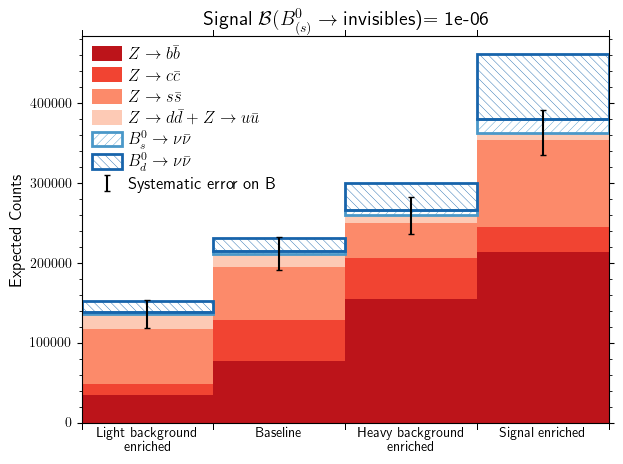

({'p8_ee_Zbb_ecm91': array([[ 76506.59679649, 155080.93945234],
         [ 35151.6796092 , 212977.82351455]]),
  'p8_ee_Zcc_ecm91': array([[51991.80101895, 50547.58432398],
         [12997.95025474, 31772.76728936]]),
  'p8_ee_Zss_ecm91': array([[ 66551.17844443,  43733.6315492 ],
         [ 68452.6406857 , 108383.34775236]]),
  'p8_ee_Zud_ecm91': array([[16272.68742579,  9763.61245548],
         [19527.22491095,  9763.61245548]]),
  'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu': array([[ 3344.6504448,  7181.1919872],
         [ 2854.5011712, 16401.3631488]]),
  'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu': array([[15847.82731636, 33861.39669818],
         [13776.77218909, 81389.27480727]])},
 array([[19192.47776116, 41042.58868538],
        [16631.27336029, 97790.63795607]]),
 array([[211322.26368566, 259125.767781  ],
        [136129.49546059, 362897.55101174]]),
 array([[ 99.09537117, 174.66424886],
        [ 89.82651373, 362.9352587 ]]),
 array([[21006.45184846, 23091.12129427],
        [17705.72123736, 27

In [9]:
#load dictionary of N_remaining from spline (ie. N remaining fior different BFT cuts - essentially efficiency map)
save_path='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/no_smoothing/0995/'

with open(os.path.join(opt.set_outputpath(save_path), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict = dill.load(dill_file)

#Load dataframe with bdtlh version applied
data={}
dir = cfg.fccana_opts["outputDir"]["prelim_cuts_full"]
folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut' 
for sample in cfg.samples:
    data[sample] = pd.read_pickle(os.path.join(dir,folder,f'{sample}.pkl'))

# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)

#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus


make_final_binning_plot(full_data, interp_N_dict, signal_BF=1e-6, histbins=(2,2), nMC_plots=False, final_plot_path = 'name')
